##### Import Files / Packages

In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from inference import abc_function
from prior import GaussianPrior
from simulators import simulate_linear_regression_known_sigma
from summaries import regression_summary
from distance import euclidean_distance
from plots import plot_posterior, plot_observed_data, plot_comparison
from posterior import exact_linear_regression_posterior, sample_exact_posterior

##### Settings

In [2]:
obs_rng = np.random.default_rng(4)
exact_rng = np.random.default_rng(5)

conditions = [
    {"epsilon": 0.30, "n_simulations": 10000},
    {"epsilon": 0.30, "n_simulations": 50000},
    {"epsilon": 0.30, "n_simulations": 100000},
]

##### Define Fixed Values

In [3]:
true_theta = {"intercept": 1.0, "slope": 2.0}

noise_sd = 0.5
x = np.linspace(0, 1, 50)

##### Define Prior

In [4]:
# We use a gaussian prior since the function exact_linear_regression_posterior requires a gaussian prior for calculation (design choice)
prior_means = {"intercept": 0.0, "slope": 0.0}
prior_stds = {"intercept": 5.0, "slope": 5.0,}

prior = GaussianPrior(means = prior_means, stds = prior_stds)

# create mean and covariance matrix, assume the sample for the means and standard deviations are independent (design choice)
prior_mean = np.array([0.0, 0.0])
prior_covariance = np.diag([5.0 ** 2, 5.0 ** 2])

##### Get Observed Data

In [5]:
observed_data = simulate_linear_regression_known_sigma(true_theta, x, noise_sd, obs_rng)

##### Calculate Exact Posterior

In [6]:
posterior_mean, posterior_covariance = (
    exact_linear_regression_posterior(
        x=x,
        y=observed_data,
        noise_sd=noise_sd,
        prior_mean=prior_mean,
        prior_covariance=prior_covariance,
    )
)

##### Define Simulator and Summary Function

In [7]:
def abc_simulator(theta, rng):
    return simulate_linear_regression_known_sigma(theta, x, noise_sd, rng)

def abc_summary(y):
    return regression_summary(x, y)

##### Run ABC

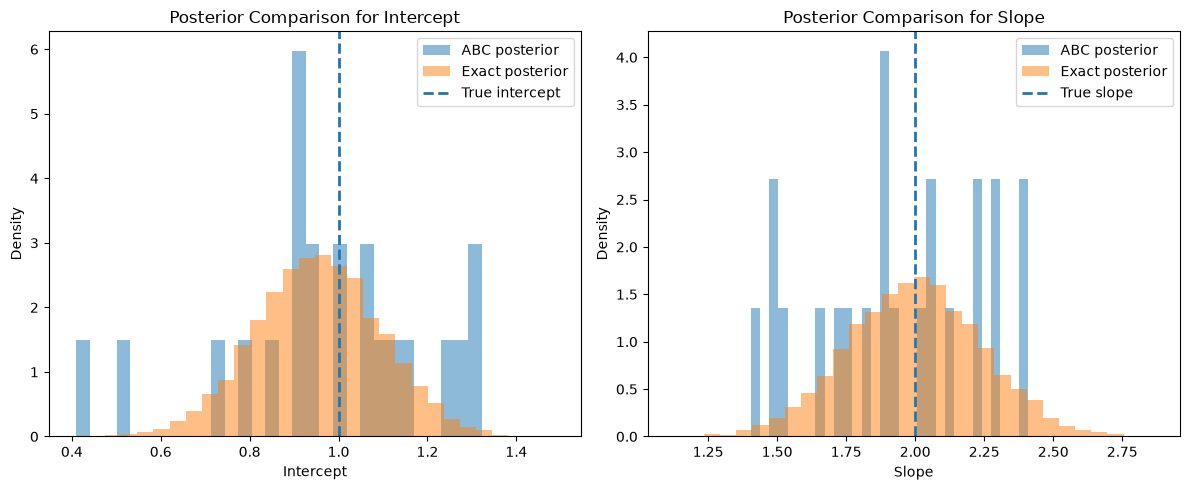

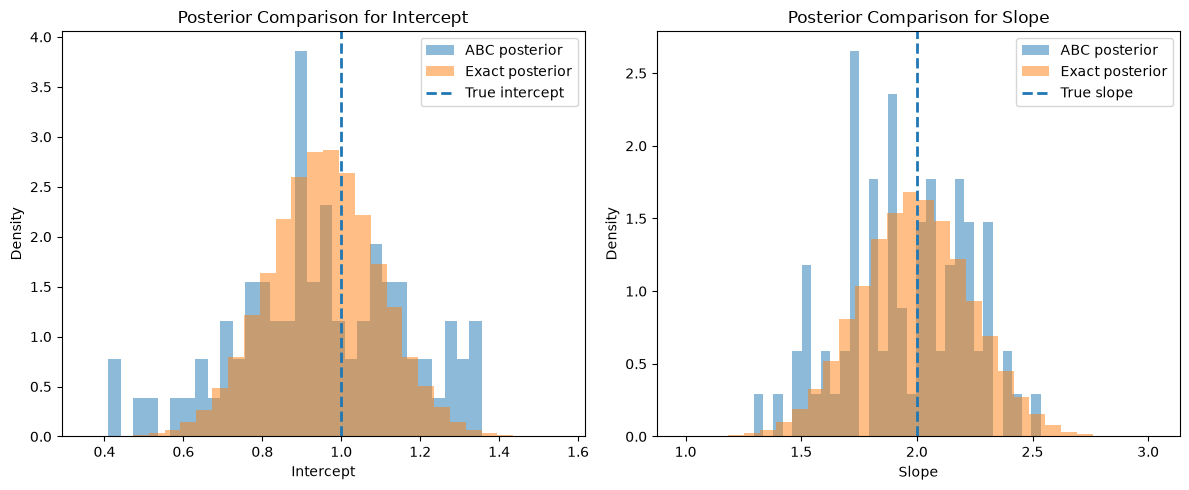

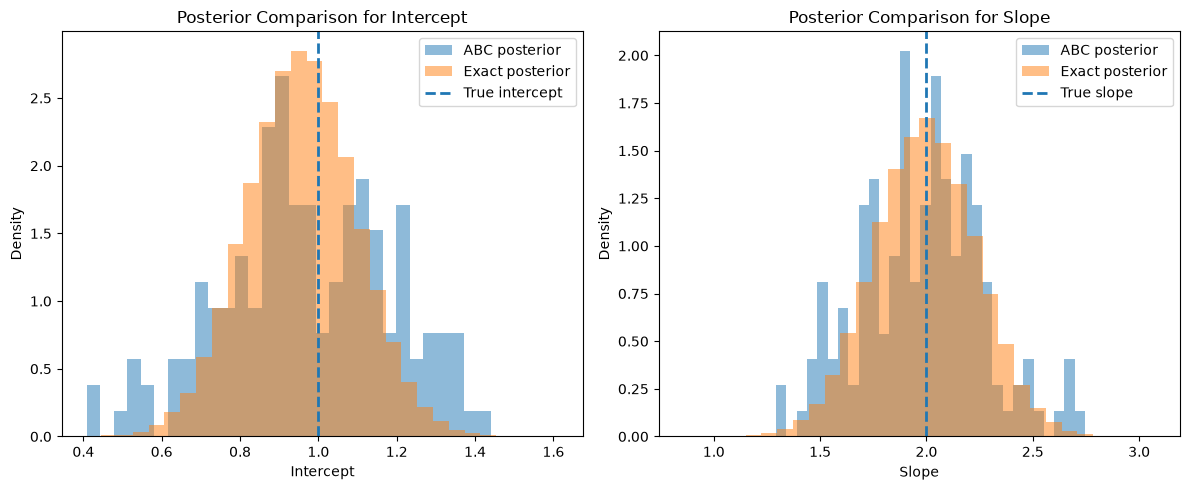

In [9]:
results = []

for condition in conditions:

    # set rng for ABC
    abc_rng = np.random.default_rng(6)

    # get epsilon and n_sims
    epsilon = condition["epsilon"]
    n_simulations = condition["n_simulations"]

    # get sample from exact posterior matching n_sims from abc sim
    exact_samples = sample_exact_posterior(posterior_mean, posterior_covariance, n_simulations, exact_rng)

    # run abc
    accepted_parameters, accepted_distances = abc_function(prior = prior,
                                                           simulator = abc_simulator,
                                                           observed_data = observed_data,
                                                           summary_fn = abc_summary,
                                                           distance_fn = euclidean_distance,
                                                           epsilon = epsilon,
                                                           n_simulations = n_simulations,
                                                           rng = abc_rng)
    
    # check if 0 parameters collected
    if len(accepted_parameters) == 0:
        print(f"No samples accepted for epsilon={epsilon}.")
        continue

    # collect array of accepted parameters of each parameter
    intercept_samples = np.array([sample["intercept"] for sample in accepted_parameters])
    slope_samples = np.array([sample["slope"] for sample in accepted_parameters])

    results.append({
        "epsilon": epsilon,
        "n_simulations": n_simulations,
        "accepted": len(accepted_parameters),
        "acceptance_rate": len(accepted_parameters) / n_simulations,
        "abc_intercept_mean": np.mean(intercept_samples),
        "abc_slope_mean": np.mean(slope_samples),
        "intercept_mean_error": (np.mean(intercept_samples) - posterior_mean[0]),
        "slope_mean_error": (np.mean(slope_samples) - posterior_mean[1]),
    })

    plot_comparison(
        accepted_parameters,
        exact_samples,
        true_theta["intercept"],
        true_theta["slope"],
    )

    plt.show()

##### Get Results

In [10]:
results_df = pd.DataFrame(results)
results_df

,epsilon,n_simulations,accepted,acceptance_rate,abc_intercept_mean,abc_slope_mean,intercept_mean_error,slope_mean_error
0,0.3,10000,22,0.00220,0.977481,1.932783,0.021106,-0.061136
1,0.3,50000,82,0.00164,0.948479,1.949386,-0.007896,-0.044533
2,0.3,100000,153,0.00153,0.968846,1.976497,0.012471,-0.017422
